# Exploratory Data Analysis for ECG (Electrocardiogram) signal

Type: Heart electrical signal\
Unit: millivolts (mV)

ECG measures electrical activity of the heart.

It helps calculate:
- Heart Rate (HR)
- Heart Rate Variability (HRV)

**Why ECG is critical for stress**

Stress activates the sympathetic nervous system, causing:
| Condition  | Heart Rate |
| ---------- | ---------- |
| Relaxed    | lower HR   |
| Stress     | higher HR  |
| Meditation | stable HRV |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../Dataset/S2_chest_data.csv")
accept_label = [1, 2, 3, 4]
df = df[df["Label"].isin(accept_label)]

nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return "stressed"
    elif label in nStr:
        return "not stressed"
    else:
        return "unknown"

df["target"] = df["Label"].apply(apply_target)

df.head(2)

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp,Label,target
214583,0.8914,-0.1102,-0.2576,0.030945,-0.003708,5.710983,29.083618,1.191711,1,not stressed
214584,0.8926,-0.1086,-0.2544,0.033646,-0.014145,5.719376,29.122437,1.139832,1,not stressed


### EDA Starts from here

In [3]:
df["ECG"].describe()

count    2.022299e+06
mean     1.189813e-03
std      1.364764e-01
min     -1.499405e+00
25%     -6.037903e-02
50%      1.199341e-02
75%      4.618835e-02
max      1.415726e+00
Name: ECG, dtype: float64

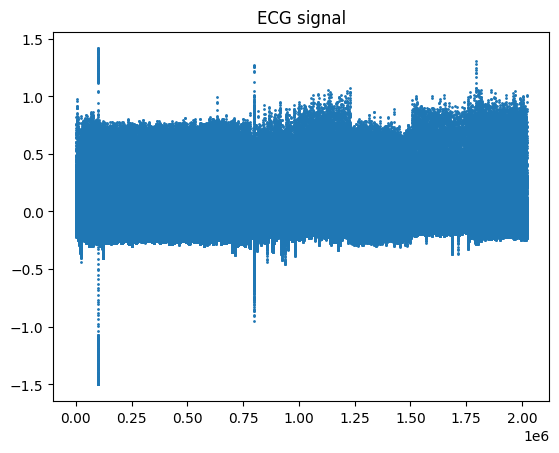

In [4]:
plt.scatter(range(len(df)), df["ECG"], s=1)
plt.title("ECG signal")
plt.show()

In [21]:
str_EDA = df[df["target"] == "stressed"]
nStr_EDA = df[df["target"] == "not stressed"]

In [22]:
from sklearn.utils import resample

# majority class
low_stress = nStr_EDA

# minority class
high_stress = str_EDA

low_downsampled = resample(
    low_stress,
    replace=False,
    n_samples=len(high_stress),
    random_state=42
)

balanced = pd.concat([low_downsampled, high_stress]).sample(frac=1)

In [33]:
str_EDA = balanced[balanced["target"] == "stressed"]
nStr_EDA = balanced[balanced["target"] == "not stressed"]

In [25]:
print(len(str_EDA))
print(len(nStr_EDA))

430500
430500


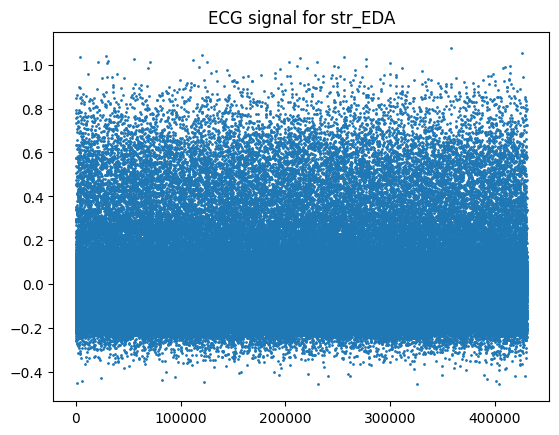

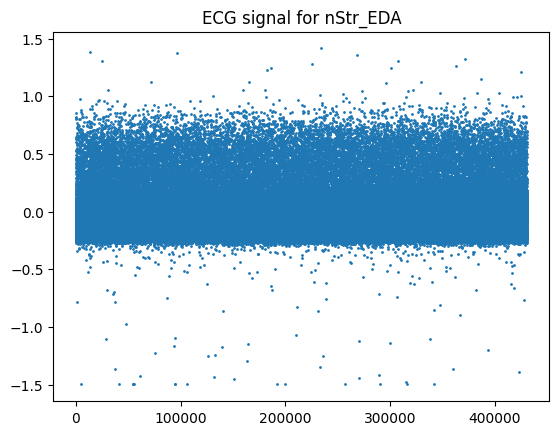

In [34]:
plt.scatter(range(len(str_EDA)), str_EDA["ECG"], s=1)
plt.title("ECG signal for str_EDA")
plt.show()

plt.scatter(range(len(nStr_EDA)), nStr_EDA["ECG"], s=1)
plt.title("ECG signal for nStr_EDA")
plt.show()

### Removing the outlier of stress class

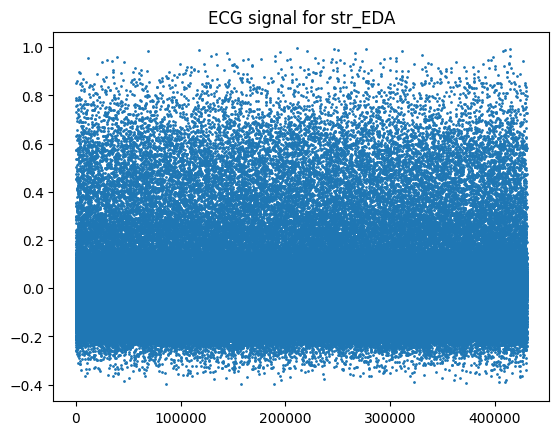

In [36]:
upper_limit = 1.0
lower_limit = -0.4

str_EDA = str_EDA[(str_EDA["ECG"] <= upper_limit) & (str_EDA["ECG"] >= lower_limit)]

plt.scatter(range(len(str_EDA)), str_EDA["ECG"], s=1)
plt.title("ECG signal for str_EDA")
plt.show()

### Removing the outlier of non stress data

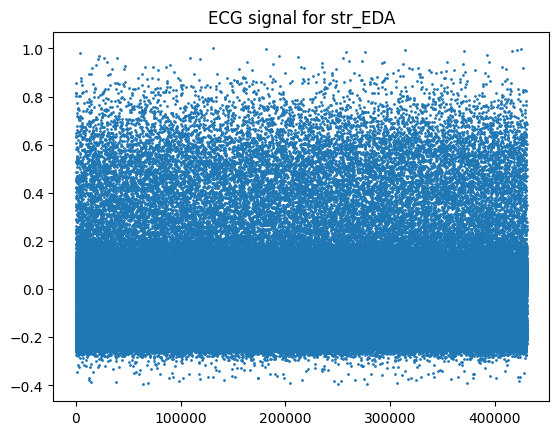

In [ ]:
upper_limit = 1.0
lower_limit = -0.4

nStr_EDA = nStr_EDA[(nStr_EDA["ECG"] <= upper_limit) & (nStr_EDA["ECG"] >= lower_limit)]

plt.scatter(range(len(nStr_EDA)), nStr_EDA["ECG"], s=1)
plt.title("ECG signal for nStr_EDA")
plt.show()

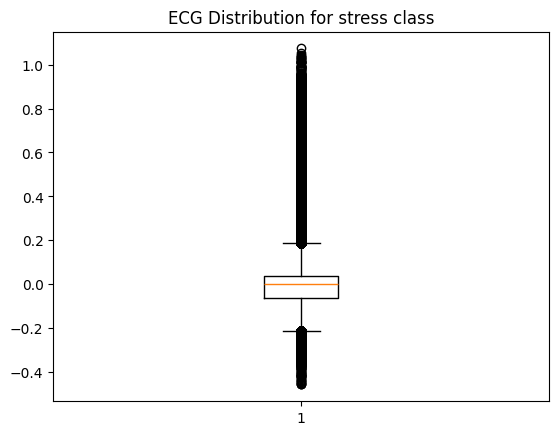

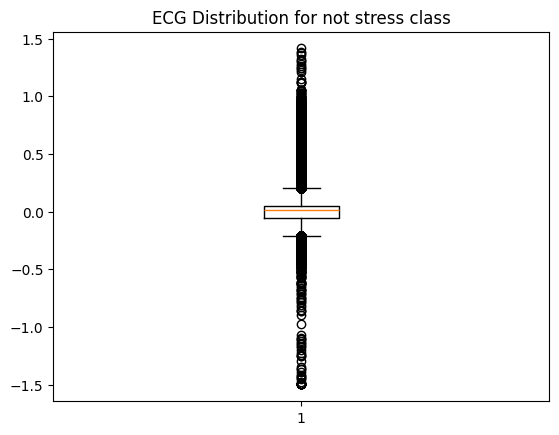

In [27]:
plt.boxplot(str_EDA["ECG"])
plt.title("ECG Distribution for stress class")
plt.show()

plt.boxplot(nStr_EDA["ECG"])
plt.title("ECG Distribution for not stress class")
plt.show()

### Removing the outlier of stress class

C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_27272\3853010930.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = str_EDA[(df["ECG"] >= lower) & (str_EDA["ECG"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_27272\3853010930.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = str_EDA[(df["ECG"] >= lower) & (str_EDA["ECG"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_27272\3853010930.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = str_EDA[(df["ECG"] >= lower) & (str_EDA["ECG"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_27272\3853010930.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = str_EDA[(df["ECG"] >= lower) & (str_EDA["ECG"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_27272\3853010930.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame i

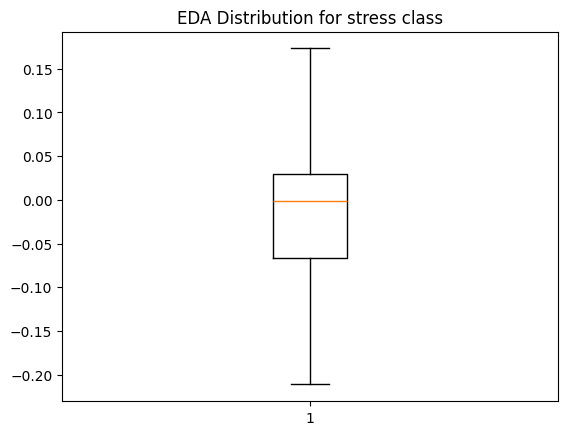

In [28]:
while True:
    Q1 = str_EDA["ECG"].quantile(0.25)
    Q3 = str_EDA["ECG"].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    new_df = str_EDA[(df["ECG"] >= lower) & (str_EDA["ECG"] <= upper)]

    # stop when no more rows are removed
    if len(new_df) == len(str_EDA):
        break

    str_EDA = new_df

plt.boxplot(str_EDA["ECG"])
plt.title("EDA Distribution for stress class")
plt.show()

### Removing the outlier of non stress class

C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_27272\2667966119.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = nStr_EDA[(df["ECG"] >= lower) & (nStr_EDA["ECG"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_27272\2667966119.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = nStr_EDA[(df["ECG"] >= lower) & (nStr_EDA["ECG"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_27272\2667966119.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = nStr_EDA[(df["ECG"] >= lower) & (nStr_EDA["ECG"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_27272\2667966119.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = nStr_EDA[(df["ECG"] >= lower) & (nStr_EDA["ECG"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_27272\2667966119.py:10: UserWarning: Boolean Series key will be reindexed to match Dat

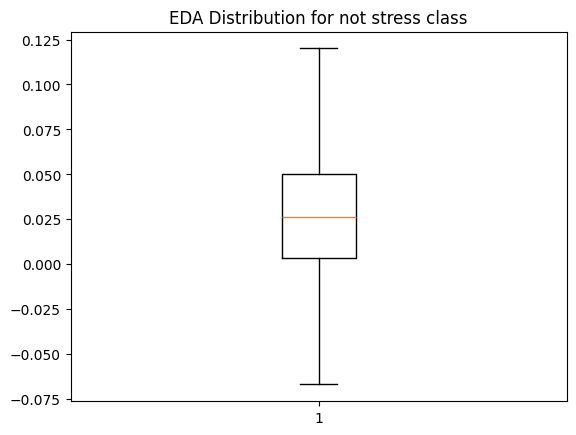

In [29]:
while True:
    Q1 = nStr_EDA["ECG"].quantile(0.25)
    Q3 = nStr_EDA["ECG"].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    new_df = nStr_EDA[(df["ECG"] >= lower) & (nStr_EDA["ECG"] <= upper)]

    # stop when no more rows are removed
    if len(new_df) == len(nStr_EDA):
        break

    nStr_EDA = new_df

plt.boxplot(nStr_EDA["ECG"])
plt.title("EDA Distribution for not stress class")
plt.show()

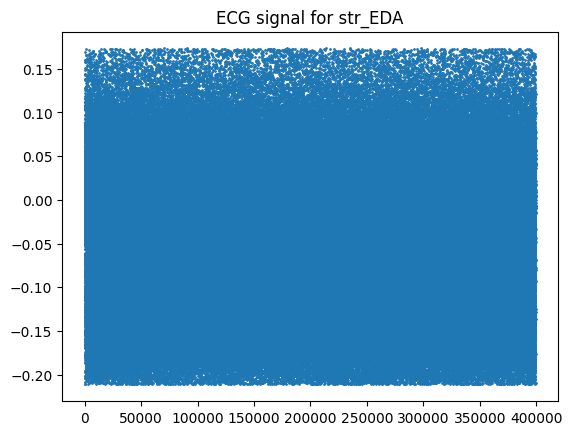

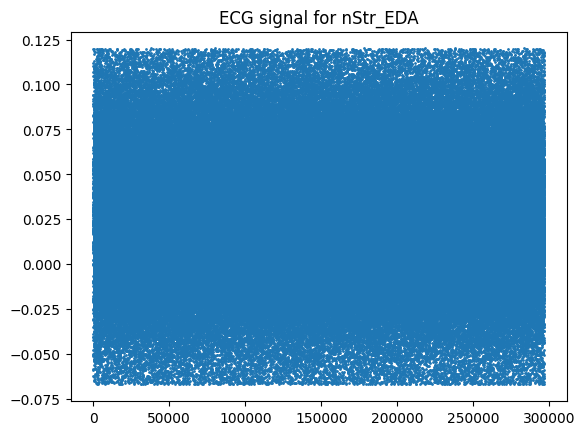

In [30]:
plt.scatter(range(len(str_EDA)), str_EDA["ECG"], s=1)
plt.title("ECG signal for str_EDA")
plt.show()

plt.scatter(range(len(nStr_EDA)), nStr_EDA["ECG"], s=1)
plt.title("ECG signal for nStr_EDA")
plt.show()